<a href="https://colab.research.google.com/github/qhansen628/FMRI_Similarity_CNN/blob/Collecting-updates-2025/RSA_with_Neural_Net_Teacher.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# prompt: give me code to unzip stimuli.zip

!unzip /content/train.zip


Streaming output truncated to the last 5000 lines.
  inflating: train/sunflower/sunflower_s_000188.png  
  inflating: __MACOSX/train/sunflower/._sunflower_s_000188.png  
  inflating: train/sunflower/sunflower_s_000177.png  
  inflating: __MACOSX/train/sunflower/._sunflower_s_000177.png  
  inflating: train/sunflower/sunflower_s_000163.png  
  inflating: __MACOSX/train/sunflower/._sunflower_s_000163.png  
  inflating: train/sunflower/sunflower_s_000375.png  
  inflating: __MACOSX/train/sunflower/._sunflower_s_000375.png  
  inflating: train/sunflower/sunflower_s_000413.png  
  inflating: __MACOSX/train/sunflower/._sunflower_s_000413.png  
  inflating: train/sunflower/sunflower_s_000407.png  
  inflating: __MACOSX/train/sunflower/._sunflower_s_000407.png  
  inflating: train/sunflower/sunflower_s_000361.png  
  inflating: __MACOSX/train/sunflower/._sunflower_s_000361.png  
  inflating: train/sunflower/sunflower_s_000349.png  
  inflating: __MACOSX/train/sunflower/._sunflower_s_000349.png

In [ ]:
import tensorflow as tf

def parse_line(line):
    parts = tf.strings.split(line)
    # Ensure exactly 3 elements
    valid = tf.size(parts) == 3
    return parts, valid

def load_and_preprocess_image(path, image_size=(32,32)):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, image_size)
    image = tf.image.rgb_to_grayscale(image)
    image = image / 255.0
    return image

def build_similarity_datasets(text_file, batch_size=64, val_split=0.2, image_size=(32,32), shuffle=True):
    ds = tf.data.TextLineDataset(text_file)

    if shuffle:
        ds = ds.shuffle(buffer_size=10000)

    # Parse lines and filter invalid ones
    ds = ds.map(parse_line, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.filter(lambda parts, valid: valid)
    ds = ds.map(lambda parts, _: (parts[0], parts[1], tf.strings.to_number(parts[2], tf.float32)),
                num_parallel_calls=tf.data.AUTOTUNE)

    # Compute size once efficiently
    total_size = ds.reduce(0, lambda x, _: x + 1).numpy()
    val_size = int(total_size * val_split)

    # Enumerate and split
    ds = ds.enumerate()

    train_ds = ds.filter(lambda i, _: i >= val_size).map(lambda _, data: data)
    val_ds = ds.filter(lambda i, _: i < val_size).map(lambda _, data: data)

    # Load images efficiently
    def load_images(i1, i2, s):
        img1 = load_and_preprocess_image(i1, image_size)
        img2 = load_and_preprocess_image(i2, image_size)
        return img1, img2, s

    train_ds = train_ds.map(load_images, num_parallel_calls=tf.data.AUTOTUNE)
    val_ds = val_ds.map(load_images, num_parallel_calls=tf.data.AUTOTUNE)

    train_ds = train_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    val_ds = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return train_ds, val_ds


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image_dataset_from_directory

def build_cnn_model(input_shape=(227,227,1), num_classes=100, rep_layer_name='representation'):
    inputs = Input(shape=input_shape, name='input_image')

    x = Conv2D(32, (3,3), activation='relu')(inputs)
    x = MaxPooling2D((2,2))(x)
    x = Conv2D(64, (3,3), activation='relu')(x)
    x = MaxPooling2D((2,2))(x)
    x = Flatten()(x)
    representation = Dense(128, activation='relu', name=rep_layer_name)(x)
    outputs = Dense(num_classes, activation='softmax')(representation)

    # Full classification model
    model = Model(inputs=inputs, outputs=outputs, name='classification_model')

    # Representation extractor
    rep_model = Model(inputs=inputs, outputs=representation, name='representation_model')

    return model, rep_model




def build_classification_dataset(txt_file, batch_size=64, image_size=(32,32), shuffle=True):
    def parse_line(line):
        parts = tf.strings.split(line)
        img_path = parts[0]
        label = tf.strings.to_number(parts[1], tf.int32)
        return img_path, label

    def load_and_preprocess_image(img_path, label):
        image = tf.io.read_file(img_path)
        image = tf.image.decode_png(image, channels=3)
        image = tf.image.resize(image, image_size)

        # Convert to grayscale
        #image = tf.image.rgb_to_grayscale(image)

        # Normalize [0,1]
        image = image / 255.0

        return image, label

    ds = tf.data.TextLineDataset(txt_file)
    if shuffle:
        ds = ds.shuffle(10000)

    ds = ds.map(parse_line, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return ds



In [ ]:
def train_classification(model, train_ds, val_ds, epochs=10):
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs
    )

    return history

def train_similarity(rep_model, train_ds, val_ds, epochs=10):
    optimizer = tf.keras.optimizers.Adam()

    train_loss_metric = tf.keras.metrics.Mean(name='train_loss')
    val_loss_metric = tf.keras.metrics.Mean(name='val_loss')

    @tf.function
    def compute_loss(img1, img2, sim_target):
        rep1 = rep_model(img1, training=True)
        rep2 = rep_model(img2, training=True)
        cosine_sim = tf.keras.losses.cosine_similarity(rep1, rep2, axis=-1)
        cosine_sim = 1 + cosine_sim  # we actually use distance
        loss = tf.keras.losses.MSE(sim_target, cosine_sim)
        return tf.reduce_mean(loss)

    @tf.function
    def train_step(img1, img2, sim_target):
        with tf.GradientTape() as tape:
            loss = compute_loss(img1, img2, sim_target)
        grads = tape.gradient(loss, rep_model.trainable_variables)
        optimizer.apply_gradients(zip(grads, rep_model.trainable_variables))
        train_loss_metric.update_state(loss)

    @tf.function
    def val_step(img1, img2, sim_target):
        loss = compute_loss(img1, img2, sim_target)
        val_loss_metric.update_state(loss)

    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        train_loss_metric.reset_state()
        val_loss_metric.reset_state()

        # Training loop
        for img1, img2, sim_target in train_ds:
            train_step(img1, img2, sim_target)

        # Validation loop
        for img1, img2, sim_target in val_ds:
            val_step(img1, img2, sim_target)

        train_loss = train_loss_metric.result().numpy()
        val_loss = val_loss_metric.result().numpy()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        print(f'Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

    return history



# Rebuild CornetZ

idea for later:
- instead of pair wise similarity loss metric
    - each image is paired with a target label, and teacher representation vector.
    - the model produces a representation vector and label for an input vector.
    - for a batch of images we take the entire batch of representation vectors and perform a vectorized operation to produce the

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Lambda
from tensorflow.keras.models import Model
def build_cornet_z_model(input_shape=(227, 227, 1), num_classes=100, rep_layer_name="IT", dropout_rate=0.5):
    def lrn_layer(x):
        return tf.nn.local_response_normalization(
            x,
            depth_radius=2,
            bias=1.0,
            alpha=2e-5,
            beta=0.75
        )

    inputs = Input(shape=input_shape, name='input_image')

    #x = Lambda(lambda img: tf.image.resize(img, (227, 227)))(inputs)

    # V1
    x = Conv2D(64, (7, 7), strides=2, padding='valid', activation='relu', name='conv1')(inputs)
    x = Lambda(lrn_layer, name='norm1')(x)
    x = MaxPooling2D(pool_size=(7, 7), strides=2, padding='valid', name='pool1')(x)

    # V2
    x = Conv2D(128, (3, 3), strides=1, padding='valid', activation='relu', name='conv2')(x)
    x = Lambda(lrn_layer, name='norm2')(x)
    x = MaxPooling2D(pool_size=(3, 3), strides=2, padding='valid', name='pool2')(x)

    # V4
    x = Conv2D(256, (3, 3), strides=1, padding='valid', activation='relu', name='conv3')(x)
    x = Lambda(lrn_layer, name='norm3')(x)
    x = MaxPooling2D(pool_size=(3, 3), strides=2, padding='valid', name='pool3')(x)

    # IT layer
    x = Conv2D(512, (3, 3), strides=1, padding='valid', activation='relu', name='conv4')(x)
    x = Lambda(lrn_layer, name='norm4')(x)
    x = MaxPooling2D(pool_size=(3, 3), strides=2, padding='valid', name=rep_layer_name)(x)

    representation = x
    flat_representation = Flatten(name='flatten_rep')(representation)

    # Classifier head
    x = Flatten(name='flatten')(representation)
    x = Dense(4096, activation='relu', name='fc6')(x)
    x = Dropout(dropout_rate, name='dropout6')(x)
    x = Dense(4096, activation='relu', name='fc7')(x)
    x = Dropout(dropout_rate, name='dropout7')(x)
    outputs = Dense(num_classes, activation='softmax', name='fc8')(x)

    classification_model = Model(inputs=inputs, outputs=outputs, name='cornet_z_model')
    rep_model = Model(inputs=inputs, outputs=flat_representation, name='rep_cornet_z_model')

    return classification_model, rep_model


In [ ]:
batch_size = 256
image_size = (227,227)

train_ds = build_classification_dataset(
    txt_file='train.txt',
    batch_size=batch_size,
    image_size=image_size,
    shuffle=True
)

# #Since images are now grayscale, input shape is (height, width, 1)
# classification_model, rep_model = build_cornet_z_model(input_shape=(227,227,3), num_classes=100)

# classification_model.compile(
#     optimizer='adam',
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

history = classification_model.fit(train_ds, epochs=30)

Epoch 1/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 81s 304ms/step - accuracy: 0.8098 - loss: 0.6427
Epoch 2/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 60s 303ms/step - accuracy: 0.8337 - loss: 0.5413
Epoch 3/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 82s 305ms/step - accuracy: 0.8401 - loss: 0.5238
Epoch 4/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 82s 304ms/step - accuracy: 0.8406 - loss: 0.5387
Epoch 5/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 82s 304ms/step - accuracy: 0.8443 - loss: 0.5102
Epoch 6/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 83s 307ms/step - accuracy: 0.8422 - loss: 0.5295
Epoch 7/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 59s 302ms/step - accuracy: 0.8441 - loss: 0.5108
Epoch 8/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 82s 305ms/step - accuracy: 0.8470 - loss: 0.5178
Epoch 9/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 82s 304ms/step - accuracy: 0.8411 - loss: 0.5255
Epoch 10/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 60s 303ms/step - accuracy: 0.8423 - loss: 0.5242
Epoch 11/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 82s 305ms/step - accuracy: 0.8439 - loss: 0.5247
Epoch 12/30
196/196

In [ ]:
classification_model.save('cornet_z_model_100epoch_apr8.keras')

# Train Teacher Model for classification


In [ ]:
batch_size = 512
image_size = (32,32)

train_ds = build_classification_dataset(
    txt_file='train.txt',
    batch_size=batch_size,
    image_size=image_size,
    shuffle=True
)

#Since images are now grayscale, input shape is (height, width, 1)
classification_model, rep_model = build_cnn_model(input_shape=(32,32,1), num_classes=100)

classification_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = classification_model.fit(train_ds, epochs=100)


Epoch 1/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 15s 102ms/step - accuracy: 0.0241 - loss: 4.5312
Epoch 2/100


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


98/98 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - accuracy: 0.1023 - loss: 4.0409
Epoch 3/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - accuracy: 0.1448 - loss: 3.7575
Epoch 4/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.1769 - loss: 3.5862
Epoch 5/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step - accuracy: 0.1989 - loss: 3.4583
Epoch 6/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.2182 - loss: 3.3473
Epoch 7/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 0.2336 - loss: 3.2675
Epoch 8/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 0.2491 - loss: 3.1928
Epoch 9/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - accuracy: 0.2572 - loss: 3.1369
Epoch 10/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - accuracy: 0.2684 - loss: 3.0782
Epoch 11/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - accuracy: 0.2808 - loss: 3.0229
Epoch 12/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 0.2903 - loss: 2.9659
Epoch 13/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - acc

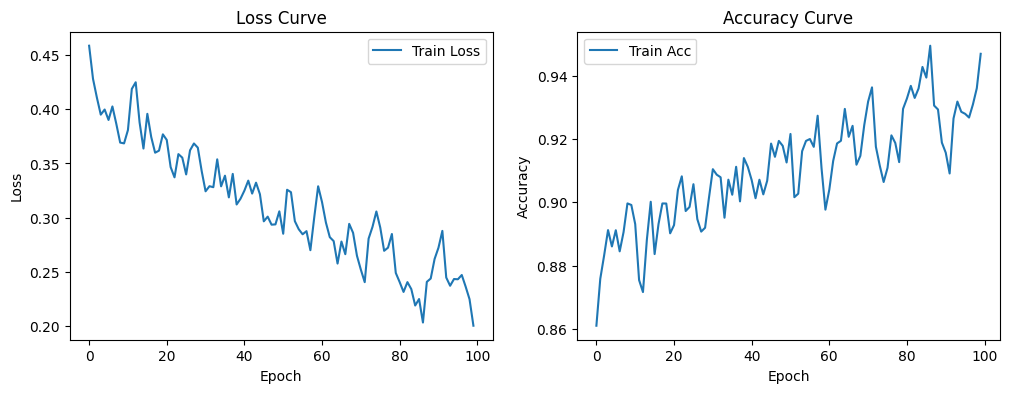

In [ ]:
import matplotlib.pyplot as plt

def plot_classification_history(history):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='Train Loss')
    #plt.plot(history.history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Curve')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='Train Acc')
   #plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy Curve')
    plt.legend()

    plt.show()
def plot_similarity_history(history):
    plt.figure(figsize=(6,4))

    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Similarity Loss Curve')
    plt.legend()

    plt.show()
plot_classification_history(history)

In [ ]:
classification_model.save('classification_model_400epoch_apr7.keras')

In [ ]:
history = classification_model.fit(train_ds, epochs=100)

Epoch 1/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.8648 - loss: 0.4465
Epoch 2/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - accuracy: 0.8776 - loss: 0.4268
Epoch 3/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - accuracy: 0.8815 - loss: 0.4152
Epoch 4/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - accuracy: 0.8921 - loss: 0.3936
Epoch 5/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.8856 - loss: 0.3976
Epoch 6/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - accuracy: 0.8931 - loss: 0.3861
Epoch 7/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - accuracy: 0.8812 - loss: 0.4101
Epoch 8/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.8919 - loss: 0.3864
Epoch 9/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - accuracy: 0.8960 - loss: 0.3749
Epoch 10/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - accuracy: 0.8995 - loss: 0.3690
Epoch 11/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - accuracy: 0.8959 - loss: 0.3725
Epoch 12/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/

# Create RSA Dataset From Neural Net

In [ ]:


import tensorflow as tf
import numpy as np
import random
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

def create_similarity_dataset(train_txt_file, rep_model, output_txt_file,
                              samples_per_class=5, image_size=(32,32), batch_size=64):

    class_to_paths = {}
    with open(train_txt_file, 'r') as file:
        for line in file:
            img_path, label = line.strip().split()
            label = int(label)
            class_to_paths.setdefault(label, []).append(img_path)

    selected_images = []
    for paths in class_to_paths.values():
        selected_images.extend(random.sample(paths, min(samples_per_class, len(paths))))

    def preprocess_image(path):
        img = tf.io.read_file(path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, image_size)
        img = tf.image.rgb_to_grayscale(img)
        img = img / 255.0
        return img

    dataset = tf.data.Dataset.from_tensor_slices(selected_images)
    dataset = dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    representations = []
    for batch in tqdm(dataset, desc='Generating representations'):
        reps = rep_model.predict(batch, verbose=0)
        representations.append(reps)

    representations = np.vstack(representations)

    # Compute cosine similarity, then convert to cosine distance
    cosine_sim = cosine_similarity(representations)
    cosine_dist = 1 - cosine_sim  # Convert to cosine distance

    num_images = len(selected_images)

    # Write pairs excluding self-pairs (upper triangle only)
    with open(output_txt_file, 'w') as out_file:
        for i in tqdm(range(num_images), desc='Writing pairs to file'):
            for j in range(i+1, num_images):
                img_path1 = selected_images[i]
                img_path2 = selected_images[j]
                dist = cosine_dist[i, j]
                out_file.write(f'{img_path1} {img_path2} {dist}\n')



In [ ]:
create_similarity_dataset(
    train_txt_file='train.txt',
    rep_model=rep_model,
    output_txt_file='similarity_dataset.txt',
    samples_per_class=1,   # Adjust number per class to control dataset size
    image_size=(32,32),
    batch_size=64         # Adjust batch_size to fit your GPU memory
)

Writing pairs to file: 100%|██████████| 100/100 [00:00<00:00, 7283.93it/s]


# Train Student Model on Representational Similarity


In [ ]:
train_ds, val_ds = build_similarity_datasets(
    text_file='similarity_dataset.txt',
    batch_size=64,
    val_split=0.1,  # automatically use 20% for validation
    image_size=(32 ,32),
    shuffle=True
)

In [ ]:

classification_student_model, rep_student_model = build_cnn_model(input_shape=(32,32,1))
# Now directly pass to your training function
history = train_similarity(rep_student_model, train_ds, val_ds, epochs=50)


In [ ]:
batch_size = 512
image_size = (32,32)

cl_train_ds = build_classification_dataset(
    txt_file='train.txt',
    batch_size=batch_size,
    image_size=image_size,
    shuffle=True
)



classification_student_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = classification_student_model.fit(cl_train_ds, epochs=50)


Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 101ms/step - accuracy: 0.0316 - loss: 4.4976
Epoch 2/50
 1/98 ━━━━━━━━━━━━━━━━━━━━ 13s 136ms/step - accuracy: 0.1055 - loss: 4.0359

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.1339 - loss: 3.8542
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.1834 - loss: 3.5538
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 11s 89ms/step - accuracy: 0.2175 - loss: 3.3744
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - accuracy: 0.2417 - loss: 3.2523
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.2579 - loss: 3.1569
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - accuracy: 0.2735 - loss: 3.0759
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 86ms/step - accuracy: 0.2887 - loss: 2.9909
Epoch 9/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - accuracy: 0.3022 - loss: 2.9222
Epoch 10/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - accuracy: 0.3084 - loss: 2.8757
Epoch 11/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - accuracy: 0.3237 - loss: 2.8129
Epoch 12/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 11s 100ms/step - accuracy: 0.3351 - loss: 2.7511
Epoch 13/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - accuracy: 

# Move to CORNetZ Model

In [ ]:
def build_cornet_z_model(input_shape=(32, 32, 1), num_classes=100, rep_layer_name="IT", dropout_rate=0.5):
    def lrn_layer(x):
        return tf.nn.local_response_normalization(
            x,
            depth_radius=2,
            bias=1.0,
            alpha=2e-5,
            beta=0.75
        )

    inputs = Input(shape=input_shape, name='input_image')

    # V1
    x = Conv2D(64, (7, 7), strides=2, padding='same', activation='relu', name='conv1')(inputs)
    x = Lambda(lrn_layer, name='norm1')(x)
    x = MaxPooling2D(pool_size=(7, 7), strides=2, padding='same', name='pool1')(x)

    # V2
    x = Conv2D(128, (3, 3), strides=1, padding='same', activation='relu', name='conv2')(x)
    x = Lambda(lrn_layer, name='norm2')(x)
    x = MaxPooling2D(pool_size=(3, 3), strides=2, padding='same', name='pool2')(x)

    # V4
    x = Conv2D(256, (3, 3), strides=1, padding='same', activation='relu', name='conv3')(x)
    x = Lambda(lrn_layer, name='norm3')(x)
    x = MaxPooling2D(pool_size=(3, 3), strides=2, padding='same', name='pool3')(x)

    # IT layer
    x = Conv2D(512, (3, 3), strides=1, padding='same', activation='relu', name='conv4')(x)
    x = Lambda(lrn_layer, name='norm4')(x)
    x = MaxPooling2D(pool_size=(3, 3), strides=2, padding='same', name=rep_layer_name)(x)

    representation = x
    flat_representation = Flatten(name='flatten_rep')(representation)

    # Classifier head
    x = Flatten(name='flatten')(representation)
    x = Dense(4096, activation='relu', name='fc6')(x)
    x = Dropout(dropout_rate, name='dropout6')(x)
    x = Dense(4096, activation='relu', name='fc7')(x)
    x = Dropout(dropout_rate, name='dropout7')(x)
    outputs = Dense(num_classes, activation='softmax', name='fc8')(x)

    classification_model = Model(inputs=inputs, outputs=outputs, name='cornet_z_model')
    rep_model = Model(inputs=inputs, outputs=flat_representation, name='rep_cornet_z_model')

    return classification_model, rep_model


In [ ]:
batch_size = 512
image_size = (32,32)

cl_train_ds = build_classification_dataset(
    txt_file='train.txt',
    batch_size=batch_size,
    image_size=image_size,
    shuffle=True
)
cornet_z_model, rep_cornet_z_model = build_cornet_z_model(input_shape=(32,32,1))
cornet_z_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = cornet_z_model.fit(cl_train_ds, epochs=50)



Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 23s 143ms/step - accuracy: 0.0130 - loss: 4.5820
Epoch 2/50


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
